# Data Collection and Preprocessing for Graduation Project

## 🔗 Builds on (AIAT 111–125)

AIAT 126 is the *graduation* project: it **assembles** what you already built across the diploma, it does not re-teach it. Open what you need:

- **AIAT 115 U2 — missing values and duplicates** (this notebook does *not* re-teach it) → [`Course 05/unit2-cleaning/examples/02_missing_values_duplicates.ipynb`](../../../Course%2005/unit2-cleaning/examples/02_missing_values_duplicates.ipynb)
- **AIAT 115 U2 — scaling and encoding, the transformer you reuse here** → [`Course 05/unit2-cleaning/examples/04_feature_transformation_scaling_encoding.ipynb`](../../../Course%2005/unit2-cleaning/examples/04_feature_transformation_scaling_encoding.ipynb)
- **AIAT 114 U1 — the preprocessing-pipeline pattern** → [`Course 04/unit1-regression-algorithms/examples/03_data_preprocessing.ipynb`](../../../Course%2004/unit1-regression-algorithms/examples/03_data_preprocessing.ipynb)
- **AIAT 116 U3 — anonymisation: what you may legally keep about a person** → [`Course 06/unit3-privacy-security/examples/07_anonymization_pseudonymization.ipynb`](../../../Course%2006/unit3-privacy-security/examples/07_anonymization_pseudonymization.ipynb)
- **AIAT 115 U5 — only if your own file is too big for memory** → [`Course 05/unit5-scaling/examples/07_large_datasets.ipynb`](../../../Course%2005/unit5-scaling/examples/07_large_datasets.ipynb)

Record every artifact you reuse in **section 6, the Prior Work Inventory**, of [`TEMPLATES/project_proposal_template.md`](../../TEMPLATES/project_proposal_template.md). It is scored at gate 1 (criterion 1.7) and re-checked at the Unit 2 design review — it is this course's **CLO2** evidence, and the official AIAT 126 description requires it.

## 📚 Learning Objectives

By completing this notebook, you will:
- Collect and acquire datasets for graduation project
- Perform comprehensive data cleaning and preprocessing
- Implement feature engineering techniques
- Validate data quality and create train/validation/test splits
- Document data collection and preprocessing procedures

## 🔗 Where this leads

**Used later in:** Course 12 — Unit 3, lesson 02, which trains on the train/validation/test split produced here.

---

This notebook covers practical activities from **Course 12, Unit 3**:
- Collecting and acquiring datasets
- Performing data cleaning and preprocessing using Python libraries
- Implementing feature engineering techniques
- Validating data quality and preparing train/validation/test splits
- Creating data exploration notebooks with visualizations

---

## Introduction

**Data Collection and Preparation** is critical for project success. Quality data leads to quality models.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Your own project dataset**, if you have one: put it at `data/my_project_data.csv` next to this
  notebook and the pipeline below will pick it up automatically
- Otherwise the notebook falls back to a real named dataset — the 1912 Titanic passenger manifest at
  `../../../Course 04/datasets/raw/titanic.csv` — so every step runs on data with real missing values,
  real categories and a real class imbalance

**Outputs:** What you'll see when you run the cells

- A missing-value report, an imputation/encoding/scaling pipeline, three EDA figures, two
  engineered features, and a stratified 60/20/20 split — all on whichever dataset was loaded.

---

---

## The model that scored over 90% in the lab and refused a fifth of the photographs in the clinic

Google's deep-learning system for detecting **diabetic retinopathy** was, by every usual measure, finished. On the retinal scans it was evaluated against it identified signs of the disease with **more than 90% accuracy**, which Google described as specialist level. It was then deployed in **eleven clinics across Thailand**, where a nurse photographs a patient's retina and a positive result sends that patient on to an ophthalmologist.

The published study of that deployment — **Beede et al., CHI 2020** — reports what happened next. The model had been trained on high-quality scans, so, sensibly, it was built to refuse any image below a quality threshold. In the clinics, nurses were photographing dozens of patients an hour, frequently in rooms that could not be darkened. **More than a fifth of the images were rejected.** Nurses who could see the disease perfectly well in a photograph the system had refused were required to retake it, sometimes repeatedly, with a queue of patients waiting; eventually the study protocol was changed so that ungradable images went to an ophthalmologist later instead of being retaken on the spot.

The accuracy number was true. It had been measured on data that did not exist in the clinic.

### What goes wrong without this

Sambasivan et al. (**CHI 2021**, reference 3 below) interviewed **53 AI practitioners** across India, East and West Africa, and the USA. They found *data cascades* — a data problem early on that compounds downstream — in **92%** of them, and described them as invisible, delayed, and usually avoidable.

In a graduation project a data cascade looks like this. In week 3 you fill 177 missing ages with the median, because it is the quickest thing that lets the next cell run. In week 8 your model has learned that one particular age is unusually informative, because a fifth of your rows now sit exactly on it. In week 12 you cannot explain your feature importances to the examiner. Nothing failed loudly. Everything downstream is slightly wrong.

This notebook's whole job is to make that decision **visible and written down at the moment you make it**, instead of discoverable at the defence.

### The same reasoning, two other domains

- **Public Health England, October 2020.** Laboratory results were collated into the legacy `.xls` Excel format, which caps a sheet at 65,536 rows. When a file filled, new rows were silently dropped rather than flagged as an error. **15,841 positive COVID-19 cases** were missing from the daily reports covering 25 September to 2 October 2020, and their contacts were not traced in time. One file-format decision, made once, that no downstream metric could see.
- **The Titanic manifest you are about to load.** `Cabin` is missing for **687 of 891** passengers (77.1%); `Age` for 177 (19.9%). The Unit 2 design lesson **drops** `Cabin` and **imputes** `Age` — the same kind of decision, taken twice, with opposite answers, because the numbers were different. That is what a data plan is: the same question asked column by column.

### This is not AIAT 115 again

Course 05 (AIAT 115) Unit 2 taught you **how** to clean data: missing values, duplicates,
outliers, encoding, scaling, and why each choice matters. **This notebook repeats none of that
teaching.** One thing changes, and it changes everything:

| AIAT 115 Unit 2 | AIAT 126 Unit 3 (here) |
|---|---|
| a dataset chosen *for* you, to demonstrate a technique | **the dataset you chose**, with whatever it happens to contain |
| the cleaning step **is** the lesson | the cleaning step is **infrastructure** for the system you designed in Unit 2 |
| "here is how to impute a missing value" | "here is the data plan your Unit 2 design committed to — execute it, and record every place the real data forced you to depart from it" |

**Do this before running the next cell.**

1. Put your own data at `data/my_project_data.csv`, next to this notebook. If it is not ready
   yet, the pipeline below falls back to a **real named dataset** — the 1912 Titanic passenger
   manifest from `Course 04/datasets/raw/titanic.csv` — so every step still runs on data
   somebody actually collected, with real missingness and a real class imbalance. It is a
   stand-in, not your project.
2. Open the AIAT 115 notebooks listed in **Builds on** above and reuse the steps that apply.
   You are *expected* to reuse them — that is what the Prior Work Inventory records, and
   rewriting them from scratch earns nothing.
3. Every departure from the Unit 2 data plan gets one line: **what changed and why**. That note
   is the evidence gate 3 asks for; a silent change is scored as scope drift.

---

In [1]:
# Setup: import the preprocessing toolkit — pandas/NumPy for the data itself,
# matplotlib/seaborn for the EDA plots, and scikit-learn's split/scale/encode
# utilities used by the cleaning pipeline below.
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Confirm the environment is ready before the pipeline cells run
print("✅ Libraries imported!")
print("Ready for data collection and preprocessing!")


✅ Libraries imported!
Ready for data collection and preprocessing!


## Part 1: Data Collection Strategies

Explore different data sources and collection methods.


In [2]:
# Map of data-collection strategies: for each source type, what it offers and
# what to watch out for — choosing a realistic, legally usable data source is
# the first real decision of the capstone, and licensing or ethics problems
# are far cheaper to catch now than after you have built on the data.
print("=" * 60)
print("Data Collection Strategies")
print("=" * 60)

# Four families of sources, each with concrete examples, advantages, and caveats
data_sources = {
    "Public Datasets": {
        "sources": [
            "Kaggle Datasets", "UCI Machine Learning Repository",
            "Google Dataset Search",
            "Papers with Code Datasets",
            "Hugging Face Datasets"
        ],
        "advantages": "Ready to use, often cleaned, documented",
        "considerations": "Check licensing, ensure relevance to your problem"
    },
    "APIs": {
        "sources": [
            "Twitter API (for social media analysis)",
            "Reddit API",
            "News APIs",
            "Government data APIs"
        ],
        "advantages": "Real-time data, structured format",
        "considerations": "API limits, authentication, rate limiting"
    },
    "Web Scraping": {
        "sources": [
            "BeautifulSoup + requests",
            "Scrapy framework",
            "Selenium for dynamic content"
        ],
        "advantages": "Access to large amounts of data",
        "considerations": "Legal and ethical considerations, robots.txt, ToS"
    },
    "Custom Collection": {
        "sources": [
            "Surveys",
            "Experiments",
            "Sensors/IoT devices"
        ],
        "advantages": "Tailored to your specific needs",
        "considerations": "Time-consuming, requires IRB approval for human subjects"
    }
}

# Print a compact card per strategy so the trade-offs sit side by side
for source_type, details in data_sources.items():
    print(f"\n{source_type}:")
    print(f"  Sources: {', '.join(details['sources'][:3])}...")
    print(f"  Advantages: {details['advantages']}")
    print(f"  Considerations: {details['considerations']}")

print("\n✅ Choose data sources aligned with your project goals and ethical guidelines!")


Data Collection Strategies

Public Datasets:
  Sources: Kaggle Datasets, UCI Machine Learning Repository, Google Dataset Search...
  Advantages: Ready to use, often cleaned, documented
  Considerations: Check licensing, ensure relevance to your problem

APIs:
  Sources: Twitter API (for social media analysis), Reddit API, News APIs...
  Advantages: Real-time data, structured format
  Considerations: API limits, authentication, rate limiting

Web Scraping:
  Sources: BeautifulSoup + requests, Scrapy framework, Selenium for dynamic content...
  Advantages: Access to large amounts of data
  Considerations: Legal and ethical considerations, robots.txt, ToS

Custom Collection:
  Sources: Surveys, Experiments, Sensors/IoT devices...
  Advantages: Tailored to your specific needs
  Considerations: Time-consuming, requires IRB approval for human subjects

✅ Choose data sources aligned with your project goals and ethical guidelines!


## Part 2: Data Cleaning and Preprocessing Pipeline

Comprehensive data cleaning workflow — run on **your** dataset.

The next cell looks for your project data at `data/my_project_data.csv`. If it is not there
yet, it loads a real fallback dataset (the 1912 Titanic passenger manifest) so that every
step below still runs on data somebody actually collected — with the missing values, odd
categories and class imbalance that come with it.

**When you switch to your own file, change the four names in the `EDIT THIS BLOCK` section**
so the pipeline knows which columns are numeric, which is categorical, and which is the target.

In [3]:
# Load the project dataset (yours if present, a real named fallback otherwise) and run the
# full cleaning pipeline on it: inspect -> impute -> encode -> scale.
# WHY a real fallback rather than random numbers: an imputation step only teaches you
# anything if the gaps are gaps somebody actually left in a record.
PROJECT_DATA = Path("data/my_project_data.csv")      # <- your own dataset goes here
FALLBACK_DATA = Path("../../../Course 04/datasets/raw/titanic.csv")

if PROJECT_DATA.exists():
    raw_data = pd.read_csv(PROJECT_DATA)
    data_source = f"YOUR project dataset ({PROJECT_DATA})"
else:
    raw_data = pd.read_csv(FALLBACK_DATA)
    data_source = f"fallback: real Titanic passenger manifest ({FALLBACK_DATA.name}, 1912)"
    print(f"ℹ️  No file at {PROJECT_DATA} — using the real fallback dataset instead.")
    print("   Drop your own CSV there and re-run: everything below adapts.\n")

# ---------------------- EDIT THIS BLOCK for your own data ----------------------
NUMERIC_FEATURES = ["Age", "Fare"]        # continuous columns
CATEGORICAL_FEATURE = "Embarked"          # one categorical column to encode
TARGET = "Survived"                       # the column you want to predict
# -------------------------------------------------------------------------------

needed = NUMERIC_FEATURES + [CATEGORICAL_FEATURE, TARGET]
missing_cols = [c for c in needed if c not in raw_data.columns]
assert not missing_cols, (
    f"Columns {missing_cols} are not in {data_source}. "
    "Update the EDIT THIS BLOCK section above with your own column names."
)

sample_data = raw_data[needed].copy()

print("=" * 60)
print("Data Cleaning Pipeline")
print("=" * 60)
print(f"Source: {data_source}")

print("\n1. Initial Data Inspection:")
print(f"   Shape: {sample_data.shape}")
print(f"   Missing values:\n{sample_data.isnull().sum()}")
print(f"   Target balance: {sample_data[TARGET].value_counts().to_dict()}")

# Handle missing values
print("\n2. Handling Missing Values:")
# Option 1: Drop rows with missing values
data_dropped = sample_data.dropna()
print(f"   After dropping: {data_dropped.shape} "
      f"({len(sample_data) - len(data_dropped)} rows lost — is that acceptable?)")

# Option 2: Fill missing values (median for numeric, mode for categorical)
# WHY median rather than mean: it survives the outliers real data is full of.
data_filled = sample_data.copy()
for col in NUMERIC_FEATURES:
    data_filled[col] = data_filled[col].fillna(data_filled[col].median())
data_filled[CATEGORICAL_FEATURE] = data_filled[CATEGORICAL_FEATURE].fillna(
    data_filled[CATEGORICAL_FEATURE].mode()[0])
print(f"   After filling: Missing values = {data_filled.isnull().sum().sum()}")
print("   Note what imputation did: it invented plausible values. Say so in your report.")

# DROP vs IMPUTE, side by side: the same decision answered two ways, so the choice is made
# on numbers instead of habit. WHY it belongs in the printed output: this is the one
# comparison every project has to make, and the report line you owe is these two numbers.
rows_lost = len(sample_data) - len(data_dropped)
cells_missing = int(sample_data.isnull().sum().sum())
# Dropping a row throws away its recorded values too - that is the hidden half of the cost
observed_discarded = rows_lost * sample_data.shape[1] - cells_missing
print("\n   DROP vs IMPUTE - the same decision, answered two ways:")
print(f"     A. drop rows -> keeps {len(data_dropped)}/{len(sample_data)} rows "
      f"({rows_lost} lost = {rows_lost / len(sample_data) * 100:.1f}%), invents nothing,")
print(f"                     but discards {observed_discarded} values that WERE recorded")
print(f"     B. impute    -> keeps {len(data_filled)}/{len(sample_data)} rows (0 lost), "
      f"invents {cells_missing} values that were not")
print(f"   CONCLUSION here: B. Discarding {observed_discarded} observed values to avoid "
      f"{cells_missing} imputed ones")
print(f"   is a bad trade on this {len(sample_data)}-row dataset. Everything below uses the "
      f"imputed table.")

# Handle categorical variables
print("\n3. Encoding Categorical Variables:")
le = LabelEncoder()
data_encoded = data_filled.copy()
data_encoded[f"{CATEGORICAL_FEATURE}_encoded"] = le.fit_transform(
    data_encoded[CATEGORICAL_FEATURE])
print(f"   Original categories: {data_filled[CATEGORICAL_FEATURE].unique().tolist()}")
print(f"   Encoded values: {sorted(data_encoded[f'{CATEGORICAL_FEATURE}_encoded'].unique().tolist())}")
print("   Careful: LabelEncoder imposes an ORDER. Use one-hot instead when there isn't one.")

# Feature scaling
print("\n4. Feature Scaling:")
scaler = StandardScaler()
data_scaled = data_encoded.copy()
data_scaled[NUMERIC_FEATURES] = scaler.fit_transform(data_scaled[NUMERIC_FEATURES])
print(f"   Features scaled: {NUMERIC_FEATURES}")
print(f"   Mean after scaling: {data_scaled[NUMERIC_FEATURES].mean().round(4).tolist()}")
print(f"   Std after scaling: {data_scaled[NUMERIC_FEATURES].std().round(4).tolist()}")

print("\n✅ Data cleaning pipeline complete!")

ℹ️  No file at data/my_project_data.csv — using the real fallback dataset instead.
   Drop your own CSV there and re-run: everything below adapts.

Data Cleaning Pipeline
Source: fallback: real Titanic passenger manifest (titanic.csv, 1912)

1. Initial Data Inspection:
   Shape: (891, 4)
   Missing values:
Age         177
Fare          0
Embarked      2
Survived      0
dtype: int64
   Target balance: {0: 549, 1: 342}

2. Handling Missing Values:
   After dropping: (712, 4) (179 rows lost — is that acceptable?)
   After filling: Missing values = 0
   Note what imputation did: it invented plausible values. Say so in your report.

   DROP vs IMPUTE - the same decision, answered two ways:
     A. drop rows -> keeps 712/891 rows (179 lost = 20.1%), invents nothing,
                     but discards 537 values that WERE recorded
     B. impute    -> keeps 891/891 rows (0 lost), invents 179 values that were not
   CONCLUSION here: B. Discarding 537 observed values to avoid 179 imputed ones
  

### Reading the two options the cell just printed

That cell did not only clean the data. It ran the comparison every project has to make, and printed both answers:

| Choice | Rows kept | What it costs |
|---|---|---|
| `dropna()` | **712 of 891** | 179 records deleted — **20.1%** of the dataset. Worse, those 179 rows were not blank: deleting them also throws away **537 values that had been recorded**, in order to avoid imputing 179 that had not. |
| median / mode impute | **891 of 891** | **179 cells** nobody ever measured — 177 ages and 2 ports — each set to the column's median or mode. |

Nothing here is free, and the printed numbers say which costs more *on this dataset*: discarding 537 observed values to avoid 179 imputed ones is a bad trade, so the notebook imputes and keeps all 891 rows. There is also no reason to assume that the passengers whose age nobody recorded are a random fifth of the passengers — dropping them changes who is in your data, not just how many.

One line in your report, carrying both numbers, is all a defensible cleaning decision has to look like:

> *"179 of 891 rows (20.1%) carried a missing value, almost all in `Age`. Dropping them would have discarded 537 recorded values as well, so `Age` was median-imputed and `Embarked` mode-imputed. 177 ages in the final data are imputed, not observed."*

Now watch what that decision does to the next figure. The histogram of `Age` will show a spike that is not in the data — those 177 imputed passengers, stacked on the median. **The spike is your imputation, drawn.** A reader who sees the figure without the sentence above will believe your population really looks like that.

### Exploratory Data Analysis (EDA) Visualizations

Before modeling, *look* at the data. Quick plots catch problems that summary
numbers hide: skewed distributions, dominant categories, and imputation
artifacts. Build plots like these for your own project dataset.

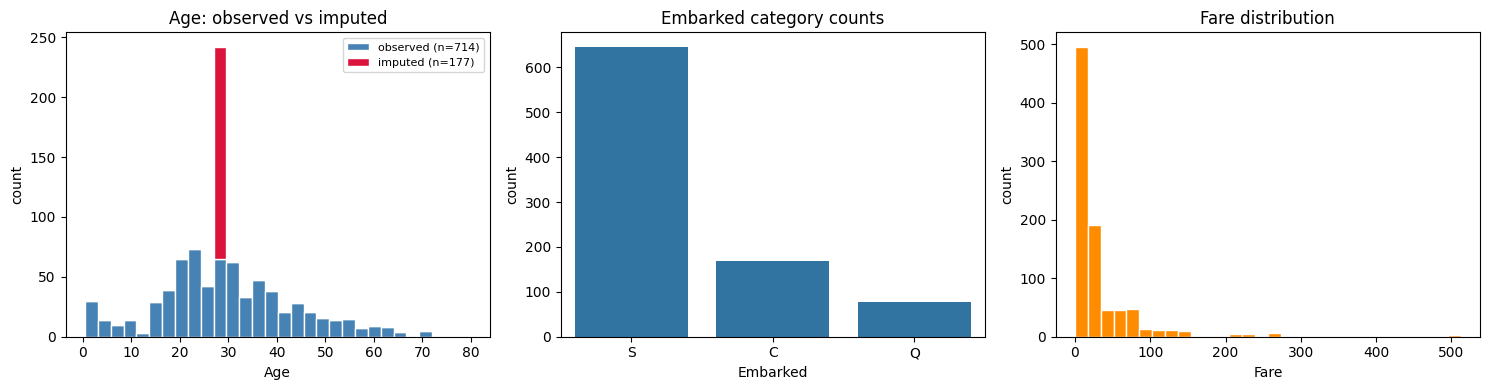

👀 Look for: the spike in 'Age' where imputation piled every missing row onto
   the median, the long right tail of 'Fare', and any category that dominates
   'Embarked'. All three change what your model can learn.
✅ EDA figures rendered — always look at distributions before you model!


In [4]:
# EDA visualizations: plot the data BEFORE modeling so surprises (skew,
# category imbalance, imputation artifacts) are caught early, not after training.
num_a, num_b = NUMERIC_FEATURES[0], NUMERIC_FEATURES[1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of the first numeric feature, SPLIT by where each value came from.
# WHAT: the lower stack is what the records actually contained; the upper stack is
# what imputation put there. WHY split it: a single-colour histogram hides the
# artifact you just created — drawing the two stacks separately makes the spike
# visible AND labels it, which is the difference between a figure that misleads a
# reader and one that warns them.
was_imputed = sample_data[num_a].isna().to_numpy()      # True where the record was blank
observed_vals = data_filled.loc[~was_imputed, num_a]
imputed_vals = data_filled.loc[was_imputed, num_a]
bins_a = np.linspace(float(data_filled[num_a].min()), float(data_filled[num_a].max()), 31)
axes[0].hist([observed_vals, imputed_vals], bins=bins_a, stacked=True,
             color=['steelblue', 'crimson'], edgecolor='white',
             label=[f'observed (n={len(observed_vals)})',
                    f'imputed (n={len(imputed_vals)})'])
axes[0].set_title(f'{num_a}: observed vs imputed')
axes[0].set_xlabel(num_a)
axes[0].set_ylabel('count')
axes[0].legend(fontsize=8)

# Bar chart of the categorical column: reveals rare or dominant categories
sns.countplot(x=CATEGORICAL_FEATURE, data=data_filled, ax=axes[1])
axes[1].set_title(f'{CATEGORICAL_FEATURE} category counts')

# Histogram of the second numeric feature: real money/measure columns are usually skewed
axes[2].hist(data_filled[num_b], bins=30, color='darkorange', edgecolor='white')
axes[2].set_title(f'{num_b} distribution')
axes[2].set_xlabel(num_b)
axes[2].set_ylabel('count')

# Render all three panels side by side
plt.tight_layout()
plt.show()

print(f"👀 Look for: the spike in '{num_a}' where imputation piled every missing row onto")
print(f"   the median, the long right tail of '{num_b}', and any category that dominates")
print(f"   '{CATEGORICAL_FEATURE}'. All three change what your model can learn.")
print('✅ EDA figures rendered — always look at distributions before you model!')

### Reading the three panels

**Left — where the red block sits is your imputation.** The blue stack is the
ages somebody wrote down in 1912. The red stack is the 177 ages nobody wrote
down, every one of them set to the same number, which is why they pile into a
single bin instead of spreading across the axis like real ages do. The stacked
bar at 28 reaches **242**, while the tallest bar built from recorded ages reaches
**73** — the artifact is more than three times the largest real feature of the
distribution. Nothing in the world produced it; a line of your code did. Show this figure without the red
colouring and a reader concludes that the commonest age aboard was 28 — and you
will have told them so.

**Middle — one category dominates.** Southampton boarded more passengers than
Cherbourg and Queenstown together, so any encoding of `Embarked` gives the model
plenty of evidence about S and comparatively little about Q. The two mode-imputed
rows also went into S, the tallest bar, where they are invisible.

**Right — the long tail is real, and it is not a mistake.** `Fare` has no imputed
values at all, so every bar is observed. Most fares sit near the left edge and a
few extend far to the right; that skew is a genuine property of 1912 ticket
prices, not a data-quality problem. It matters because the scaler in the next
step uses the mean and standard deviation, both of which those few large fares
pull upward.

**The habit to take to your own project:** plot the imputed values in a different
colour from the observed ones, every time. It costs one line and it is the single
cheapest defence against the data cascade Sambasivan et al. describe.

## 💬 Discuss

Open questions — take a position and say what evidence would move you.

1. **Drop or impute, and does the answer survive a change of stakes?** The printed numbers make imputation the better call here: dropping costs 179 of 891 rows, imputing invents 177 ages on a historical manifest where nobody is harmed by a wrong age. Now move the same 20% gap into a hospital's blood-test column, where the test is missing *because the patient was too unwell to be tested*. Which do you choose now? What would you have to look at in the data before you were entitled to choose at all?
2. **Whose lighting is your model going to meet?** Google's retinopathy system was accurate and unusable because the images in the clinic were not the images in the training set. In two sentences, describe the **worst realistic conditions** your own project's data will be collected under after your defence — the cheap phone camera, the drifting sensor, the clerk entering names in a hurry, the Arabic free-text field with three spellings of the same word. Would the pipeline you just ran survive that, or would it reject a fifth of the input? What is the cheapest experiment that would tell you *now* rather than later?
3. **Is `LabelEncoder` on `Embarked` a defect or a shortcut?** The cell warned you: encoding S/C/Q as 0/1/2 asserts that Q is twice C, and that C sits between S and Q. Argue either that this is harmless in this notebook — and say exactly which properties of the models used later make it harmless — or that it should be one-hot, and say what that costs. Then go and find the one column in **your own** project data where you have quietly done the same thing.

### Feature Engineering

Cleaning makes data *usable*; feature engineering makes it *informative*.
Below we build two new features from the existing columns — an interaction
term and a quartile bin — the same techniques you can apply to your own
project data.

In [5]:
# Feature engineering: create NEW columns from existing ones so the model
# gets signals the raw features do not expose directly.
data_features = data_scaled.copy()

# Interaction feature: the product of the two numeric features
interaction_col = f"{num_a}_x_{num_b}"
data_features[interaction_col] = data_features[num_a] * data_features[num_b]

# Binned feature: which quartile of the first numeric feature each row falls in.
# duplicates='drop' is needed on real data, where ties (e.g. many imputed medians)
# can make two quartile edges identical.
bin_col = f"{num_a}_bin"
data_features[bin_col] = pd.qcut(data_features[num_a], q=4, labels=False, duplicates='drop')

# Show the engineered columns next to the source columns they came from
print('=' * 60)
print('Engineered Features')
print('=' * 60)
print(data_features[[num_a, num_b, interaction_col, bin_col]].head())
print(f"\nQuartile bins actually produced: {sorted(data_features[bin_col].unique().tolist())}")
print(f"Columns now available: {list(data_features.columns)}")
print('\n✅ Feature engineering complete — 2 new features created!')

Engineered Features
        Age      Fare  Age_x_Fare  Age_bin
0 -0.565736 -0.502445    0.284252        0
1  0.663861  0.786845    0.522356        3
2 -0.258337 -0.488854    0.126289        1
3  0.433312  0.420730    0.182307        2
4  0.433312 -0.486337   -0.210736        2

Quartile bins actually produced: [0, 1, 2, 3]
Columns now available: ['Age', 'Fare', 'Embarked', 'Survived', 'Embarked_encoded', 'Age_x_Fare', 'Age_bin']

✅ Feature engineering complete — 2 new features created!


## Part 3: Train/Validation/Test Split

Proper data splitting for model development and evaluation.


In [6]:
# Split the prepared data into train/validation/test sets so tuning and the
# final evaluation each get data the model has never seen.
# Features: the cleaned columns plus the two engineered ones from the previous cell
feature_cols = NUMERIC_FEATURES + [f"{CATEGORICAL_FEATURE}_encoded", interaction_col, bin_col]
X = data_features[feature_cols]
y = data_features[TARGET]

# Split: 60% train, 20% validation, 20% test (stratified keeps class balance)
# First carve off the test set, then split the rest into train and validation
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Report the sizes so the 60/20/20 ratio is visible
print("=" * 60)
print("Data Splitting Strategy")
print("=" * 60)
print(f"Source: {data_source}")
print(f"Features used: {feature_cols}")
print(f"Total samples: {len(X)}")
print(f"Training set: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print("\n✅ Data split complete!")
print("📝 Use validation set for hyperparameter tuning")
print("📝 Use test set ONLY for final evaluation")

Data Splitting Strategy
Source: fallback: real Titanic passenger manifest (titanic.csv, 1912)
Features used: ['Age', 'Fare', 'Embarked_encoded', 'Age_x_Fare', 'Age_bin']
Total samples: 891
Training set: 534 (59.9%)
Validation set: 178 (20.0%)
Test set: 179 (20.1%)

✅ Data split complete!
📝 Use validation set for hyperparameter tuning
📝 Use test set ONLY for final evaluation


### Storyboard: one column, photographed at every stage

A preprocessing pipeline is a **sequence**, and a sequence is the one thing a
single figure cannot show. So instead of one plot of the finished data, the next
cell takes the same column — `Age` — and photographs it four times: as it arrived,
after imputation, after scaling, and finally as the training split the model will
actually be fitted on.

Read it left to right and ask one question at each arrow: **did this step change
the shape of the data, or only its labels?** The answer is not the same at every
arrow, and the step table underneath gives you the numbers to check the picture
against.

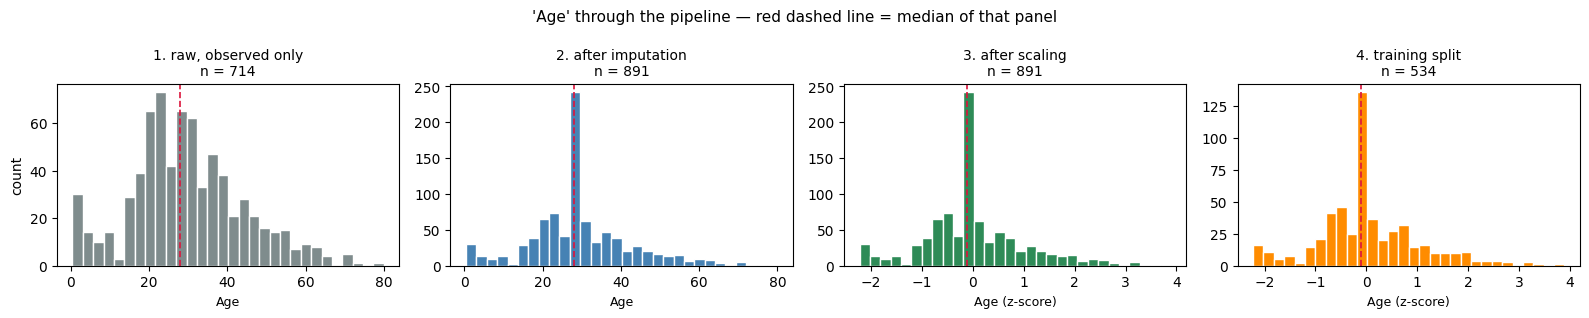

Step table — what each stage did to 'Age'
stage                      rows  still missing      mean      std  target mean
1. raw, observed only       714            177    29.699   14.526        0.406
2. after imputation         891              0    29.362   13.020        0.384
3. after scaling            891              0     0.000    1.001        0.384
4. training split           534              0     0.029    1.010        0.384

Only stage 1 -> 2 changed what the data SAYS: 177 values were added at the median.
Stages 2 -> 3 -> 4 changed the axis and the row count, not the silhouette —
which is exactly why the spike is still standing in the fourth panel.

1) Imputation narrowed the spread: std of 'Age' went 14.53 -> 13.02 (10.4% narrower). 177 identical values cannot vary,
   so the column now looks more certain than the evidence justifies.

2) The gaps are NOT random with respect to 'Survived': mean is 0.406 for rows WITH a recorded 'Age',
   and 0.294 for the 177 rows without one

In [7]:
# STEP STORYBOARD — the same column at four stages of the pipeline.
# WHAT: four snapshots of `num_a`, in the order the notebook transformed it.
# WHY a storyboard rather than four scattered figures: preprocessing damage is only
# visible as a DIFFERENCE between stages, so the stages have to sit side by side.
# COST: no new computation — every table below was already built above.
missing_mask = sample_data[num_a].isna().to_numpy()

stages = [
    ("1. raw, observed only", sample_data[num_a].dropna(), num_a, "#7f8c8d"),
    ("2. after imputation",   data_filled[num_a],          num_a, "steelblue"),
    ("3. after scaling",      data_scaled[num_a],          f"{num_a} (z-score)", "seagreen"),
    ("4. training split",     X_train[num_a],              f"{num_a} (z-score)", "darkorange"),
]

fig, axes = plt.subplots(1, len(stages), figsize=(16, 3.2))
for ax, (title, values, xlabel, color) in zip(axes, stages):
    ax.hist(values, bins=30, color=color, edgecolor='white')
    # The median line lets you track the imputation spike from panel to panel
    ax.axvline(float(values.median()), color='crimson', ls='--', lw=1.2)
    ax.set_title(f"{title}\nn = {len(values)}", fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
axes[0].set_ylabel('count')
fig.suptitle(f"'{num_a}' through the pipeline — red dashed line = median of that panel",
             fontsize=11)
plt.tight_layout()
plt.show()

# The same four stages as numbers, so the picture can be audited rather than believed.
# 'target mean' is the mean of the target column at that stage; for a 0/1 target it is
# the positive-class rate, which is what a stratified split is supposed to hold constant.
def _target_mean(series):
    try:
        return f"{pd.Series(series).astype(float).mean():.3f}"
    except (TypeError, ValueError):
        return "  n/a"

rows = [
    ("1. raw, observed only", sample_data.loc[~missing_mask, num_a],
     int(missing_mask.sum()), sample_data.loc[~missing_mask, TARGET]),
    ("2. after imputation", data_filled[num_a], 0, data_filled[TARGET]),
    ("3. after scaling", data_scaled[num_a], 0, data_scaled[TARGET]),
    ("4. training split", X_train[num_a], 0, y_train),
]

print("=" * 78)
print(f"Step table — what each stage did to '{num_a}'")
print("=" * 78)
print(f"{'stage':<24}{'rows':>7}{'still missing':>15}{'mean':>10}{'std':>9}{'target mean':>13}")
for name, values, still_missing, target in rows:
    print(f"{name:<24}{len(values):>7}{still_missing:>15}"
          f"{float(values.mean()):>10.3f}{float(values.std()):>9.3f}{_target_mean(target):>13}")

print(f"\nOnly stage 1 -> 2 changed what the data SAYS: {int(missing_mask.sum())} values "
      f"were added at the median.")
print("Stages 2 -> 3 -> 4 changed the axis and the row count, not the silhouette —")
print("which is exactly why the spike is still standing in the fourth panel.")

# Two consequences of that spike, COMPUTED from the same tables rather than asserted,
# because both are the kind of claim a project report has to be able to defend.
if missing_mask.any():
    spread_before = float(sample_data.loc[~missing_mask, num_a].std())
    spread_after = float(data_filled[num_a].std())
    shrink = (spread_before - spread_after) / spread_before * 100
    print(f"\n1) Imputation narrowed the spread: std of '{num_a}' went "
          f"{spread_before:.2f} -> {spread_after:.2f} ({shrink:.1f}% narrower). "
          f"{int(missing_mask.sum())} identical values cannot vary,")
    print("   so the column now looks more certain than the evidence justifies.")
    try:
        t_obs = float(sample_data.loc[~missing_mask, TARGET].astype(float).mean())
        t_mis = float(sample_data.loc[missing_mask, TARGET].astype(float).mean())
        print(f"\n2) The gaps are NOT random with respect to '{TARGET}': mean is "
              f"{t_obs:.3f} for rows WITH a recorded '{num_a}',")
        print(f"   and {t_mis:.3f} for the {int(missing_mask.sum())} rows without one. "
              "Being unrecorded is itself a signal —")
        print(f"   which median imputation deletes. Keep it: "
              f"df['{num_a}_was_missing'] = df['{num_a}'].isna()")
    except (TypeError, ValueError):
        print("\n2) Target column is not numeric — compare its distribution across the "
              "missing/observed groups by hand.")

### Reading the storyboard

**Each panel has its own y-axis** — look at the numbers, not the height of the ink.
That is the first thing to check on anyone's before/after figure, including your own.

- **Panel 1 → 2 is the only arrow that changed the data.** Panel 1 is 714 ages
  somebody recorded, and it has no spike: its tallest bar is **73**. Panel 2 is the
  same 714 values plus 177 copies of the median, and its tallest bar is **242** —
  which is why the y-axis had to rescale between the two panels. A step that forces
  the axis to triple is not a formatting step.
- **Panel 2 → 3 changed the labels, nothing else.** Scaling is a subtraction and a
  division: the silhouette is identical, only the x-axis now reads −2 to 4 instead of
  0 to 80. If a "transformation" ever changes the silhouette, you did something other
  than scale.
- **Panel 3 → 4 changed the count, not the shape.** The training split keeps 534 of
  891 rows — 60% — and every bar shrinks roughly in proportion, the spike included:
  it falls from **242 to 136**. The stratified split did its job: the step table shows
  the target mean holding at **0.384** across stages 2, 3 and 4.
- **The spike survives all four panels.** This is the point of the storyboard. A
  decision you made in one line, at stage 2, is still sitting in the data your model
  gets fitted on at stage 4. Preprocessing artifacts do not wash out downstream; they
  are inherited.

**And the two numbers the cell computed underneath are the ones to put in your report.**
The spread of `Age` fell from 14.53 to 13.02 — a tenth of the column's variability was
manufactured away, because 177 identical values cannot vary. Worse, survival averages
**0.406** among passengers whose age was recorded and **0.294** among the 177 whose age
was not. The gaps are not random: *having no recorded age was itself predictive*, and
median imputation is the step that threw that signal away. This is the concrete case
for the one-line defence in **⚠️ Where this breaks** below — keep an
`Age_was_missing` flag and let the model decide.

### Testing the assumption imputation made for you

The storyboard showed **what** median imputation did to the column. It did not ask
whether doing it was safe, and that question has an answer in this data.

Filling every gap with one number is only harmless if the gaps are scattered at
random across the dataset. If instead the missing rows are *a particular kind of
row*, then the median you poured in is a statement about a group that never made
it — and the model inherits that statement. This is not a matter of opinion: two
group-bys settle it, and the next figure draws both.

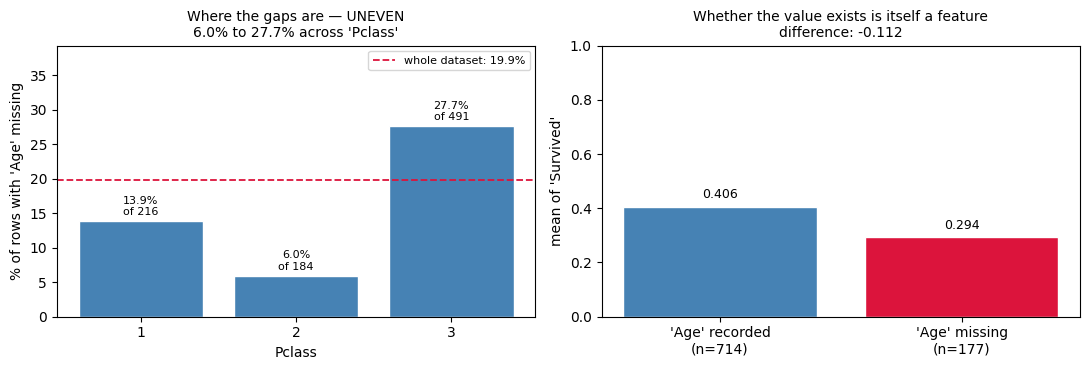

Is 'Age' missing at random?
    Pclass    rows   missing     rate        median Age
         1     216        30    13.9%              37.0
         2     184        11     6.0%              29.0
         3     491       136    27.7%              24.0

Spread between the highest and lowest missing rate: 21.7 percentage points.
Every gap, in every group, was filled with the SAME number: 28.0 (the median of all observed rows).
Compare that against the last column above — the difference is the systematic error
imputation wrote into each group of 'Pclass'.

Keep the fact instead of erasing it — one line, before any imputation:
    df['Age_was_missing'] = df['Age'].isna()


In [8]:
# MISSING-AT-RANDOM TEST — the assumption behind every median imputation, drawn.
# WHAT you are looking at: LEFT = how often `num_a` is missing inside each level of
# another column; RIGHT = the target rate for rows that HAVE the value versus rows
# that do not.
# WHY it matters: "missing at random" is assumed silently by the one-line fillna
# above. If either panel is uneven, the gaps carry information that imputation
# deletes — and the cure is one extra column, not a cleverer imputer.
# WHY both axes start at zero: these are rates, and a bar chart that starts
# anywhere else exaggerates whatever it is showing.
# COST: two group-bys on tables already in memory — no new computation.
if not missing_mask.any():
    print(f"'{num_a}' has no missing values here, so there is nothing to test.")
else:
    # Choose a grouping column automatically: the first fully-recorded column of the
    # ORIGINAL file with a handful of levels. On the Titanic fallback that is `Pclass`
    # (ticket class). For your own dataset, set GROUP_COL by hand to the column you suspect.
    GROUP_COL = None
    for cand in raw_data.columns:
        if cand in (num_a, TARGET):
            continue
        if raw_data[cand].notna().all() and 2 <= raw_data[cand].nunique() <= 8:
            GROUP_COL = cand
            break

    fig, (ax_grp, ax_tgt) = plt.subplots(1, 2, figsize=(11, 3.8))

    # --- LEFT: is the missing rate the same in every group? ---
    if GROUP_COL is None:
        ax_grp.axis("off")
        ax_grp.text(0.5, 0.5, "no low-cardinality column\nto group by",
                    ha="center", va="center", fontsize=10)
        grp_spread = float("nan")
    else:
        miss_rate = raw_data.groupby(GROUP_COL)[num_a].apply(lambda s: s.isna().mean())
        grp_n = raw_data.groupby(GROUP_COL)[num_a].size()
        overall_rate = float(raw_data[num_a].isna().mean())
        bars = ax_grp.bar([str(i) for i in miss_rate.index], miss_rate.to_numpy() * 100,
                          color="steelblue", edgecolor="white")
        # the dataset-wide rate: the single number an imputer implicitly assumes applies everywhere
        ax_grp.axhline(overall_rate * 100, color="crimson", ls="--", lw=1.3,
                       label=f"whole dataset: {overall_rate * 100:.1f}%")
        for b, v, k in zip(bars, miss_rate.to_numpy(), grp_n.to_numpy()):
            ax_grp.text(b.get_x() + b.get_width() / 2, v * 100 + 0.8,
                        f"{v * 100:.1f}%\nof {k}", ha="center", fontsize=8)
        grp_spread = float((miss_rate.max() - miss_rate.min()) * 100)
        verdict = "UNEVEN" if grp_spread >= 5 else "roughly even"
        ax_grp.set_ylim(0, float(miss_rate.max()) * 100 * 1.42)
        ax_grp.set_xlabel(GROUP_COL)
        ax_grp.set_ylabel(f"% of rows with '{num_a}' missing")
        ax_grp.set_title(f"Where the gaps are — {verdict}\n"
                         f"{miss_rate.min() * 100:.1f}% to {miss_rate.max() * 100:.1f}% "
                         f"across '{GROUP_COL}'", fontsize=10)
        ax_grp.legend(fontsize=8)

    # --- RIGHT: does having the value recorded predict the target? ---
    try:
        tgt = sample_data[TARGET].astype(float)
        obs_rate = float(tgt[~missing_mask].mean())
        mis_rate = float(tgt[missing_mask].mean())
        labels = [f"'{num_a}' recorded\n(n={int((~missing_mask).sum())})",
                  f"'{num_a}' missing\n(n={int(missing_mask.sum())})"]
        bars = ax_tgt.bar(labels, [obs_rate, mis_rate],
                          color=["steelblue", "crimson"], edgecolor="white")
        for b, v in zip(bars, [obs_rate, mis_rate]):
            ax_tgt.text(b.get_x() + b.get_width() / 2, v + 0.03, f"{v:.3f}",
                        ha="center", fontsize=9)
        ax_tgt.set_ylim(0, 1.0)
        ax_tgt.set_ylabel(f"mean of '{TARGET}'")
        ax_tgt.set_title(f"Whether the value exists is itself a feature\n"
                         f"difference: {mis_rate - obs_rate:+.3f}", fontsize=10)
    except (TypeError, ValueError):
        ax_tgt.axis("off")
        ax_tgt.text(0.5, 0.5, f"'{TARGET}' is not numeric —\ncompare its classes by hand",
                    ha="center", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()

    # The picture as numbers, so it can be audited rather than believed.
    print("=" * 72)
    print(f"Is '{num_a}' missing at random?")
    print("=" * 72)
    if GROUP_COL is not None:
        # The value fillna() actually used: the median of the rows that HAVE a value.
        fill_value = float(sample_data[num_a].median())
        print(f"{GROUP_COL:>10}{'rows':>8}{'missing':>10}{'rate':>9}"
              f"{'median ' + num_a:>18}")
        for level, k in grp_n.items():
            sub = raw_data.loc[raw_data[GROUP_COL] == level, num_a]
            nm = int(sub.isna().sum())
            print(f"{str(level):>10}{int(k):>8}{nm:>10}{nm / int(k) * 100:>8.1f}%"
                  f"{float(sub.median()):>18.1f}")
        print(f"\nSpread between the highest and lowest missing rate: {grp_spread:.1f} "
              f"percentage points.")
        print(f"Every gap, in every group, was filled with the SAME number: {fill_value:.1f} "
              f"(the median of all observed rows).")
        print("Compare that against the last column above — the difference is the "
              "systematic error")
        print(f"imputation wrote into each group of '{GROUP_COL}'.")
    print(f"\nKeep the fact instead of erasing it — one line, before any imputation:")
    print(f"    df['{num_a}_was_missing'] = df['{num_a}'].isna()")

### Reading the two panels

Both panels are drawn on axes that start at zero, so the heights are the rates.
The numbers below are the ones the Titanic fallback produces; with your own CSV in
`data/my_project_data.csv` the cell recomputes all of them.

**Left — the gaps are concentrated, not scattered.** `Age` is missing for **27.7%
of the 491 third-class passengers**, **13.9% of the 216 in first class** and only
**6.0% of the 184 in second** — a spread of nearly **22 percentage points** between
the tallest and shortest bar. The red dashed line is the one number median
imputation acts on: the dataset-wide rate of 19.9%. Every bar that misses that line
is a group the imputer is handling with somebody else's average.

**And every one of those gaps received the same number.** The median of all 714
observed ages is **28.0**, so 28.0 went into all 177 blanks — but the observed
median is **37.0** in first class, **29.0** in second and **24.0** in third (the
last column of the table the cell printed). Third class supplies **136 of the 177**
imputed ages, and every one of those passengers was aged up by about four years
against their own class, while the 30 first-class blanks were made nine years
younger than theirs. That is not rounding. It is a systematic shift, applied
hardest to the group that had the most gaps to begin with.

**Right — being unrecorded predicts the outcome.** Survival averages **0.406**
among the 714 passengers whose age was written down and **0.294** among the 177
whose age was not: a gap of **−0.112**, which is roughly the size of a real feature.
The blank itself carries signal. Median imputation is the step that erases it,
because after `fillna` the two groups look identical in the `Age` column.

**So the honest sequence is: flag first, then fill.** `df["Age_was_missing"] =
df["Age"].isna()` costs one line and one column, keeps the 0.112 the right panel
just measured, and lets the model decide whether it matters. Reach for a
sophisticated imputer only after you have done the cheap thing — and never report
an imputed column without saying which rows were imputed.

## ⚠️ Where this breaks

Every step above is a default, and a default is wrong on somebody's data. Here is where these particular ones fail.

- **Median imputation assumes the gaps are missing at random.** They frequently are not, and on this dataset they are not: the figure above measured `Age` missing for **27.7%** of third-class passengers against **6.0%** of second-class ones. Filling every gap with a single median makes third class look like the average passenger, and every model fitted afterwards inherits the distortion. **The cheaper, safer move is to keep the information rather than replace it:** `df["Age_was_missing"] = df["Age"].isna()` costs one line, preserves the fact that the record was incomplete, and lets the model decide whether incompleteness matters. Do that before reaching for anything more sophisticated than a median.
- **`LabelEncoder` on a feature asserts an order you did not mean.** It is fine for a target column, and usually survivable for tree-based models, which split on values rather than measuring distances between them. It is **not** safe for anything that computes a distance or fits a coefficient — logistic regression, SVM, k-NN, k-means, any neural network. `Embarked` has three levels here, so one-hot costs two extra columns. Prefer it unless the categories genuinely have an order (small < medium < large).
- **The scaler in this notebook is fitted on everything, before the split.** That is convenient for showing the steps one at a time, and it is **leakage** in a real project: the mean and standard deviation of your test rows have already influenced your training features. The fix is the one the Unit 2 lesson uses — put the scaler inside a `Pipeline`, which can only ever be fitted on the training split. Your gate-3 code must do it that way; this notebook separates the steps so you can see each one.
- **The engineered features here are demonstrations, not recommendations.** `Age × Fare` and an `Age` quartile bin are shown because they are the two cheapest kinds of feature to construct. Neither has been shown to help — **nothing in this notebook measures whether they do.** A feature you have not measured is a feature you should not keep; notebook 02 of this unit and Unit 4 are where you find out. Adding features without measuring them is exactly how a project ends up with columns nobody can explain at the defence.
- **60/20/20 on 891 rows leaves a 178-row validation set,** where one prediction is worth 0.56% and any difference smaller than about two percentage points is noise. **When NOT to use a single held-out split:** below roughly a thousand rows, report cross-validated scores *with their spread* instead of one held-out number, and expect the number to move when you change the seed.
- **None of this covers data you are not allowed to have.** Nothing above checks a licence, a lawful basis for processing, or whether the file contains personal data — and no imputation strategy repairs a dataset you may not legally use. That check belongs in week 1, with the AIAT 116 U3 notebook linked at the top of this lesson, not in the cleaning step.

## Summary

### Key Steps in Data Collection & Preparation:
1. **Data Collection**: Identify and acquire relevant datasets
2. **Data Inspection**: Understand data structure, types, distributions
3. **Data Cleaning**: Handle missing values, outliers, inconsistencies
4. **Feature Engineering**: Create meaningful features from raw data
5. **Data Splitting**: Train/Validation/Test sets (60/20/20 or 70/15/15)
6. **Documentation**: Document all preprocessing steps for reproducibility

### Best Practices:
- Always check data quality before modeling
- Document all preprocessing steps
- Save cleaned datasets for reproducibility
- Use stratified splitting for imbalanced data
- Validate data representativeness

### Running this on your own project data
1. Save your dataset as `data/my_project_data.csv` next to this notebook.
2. Edit the four names in the `EDIT THIS BLOCK` section (two numeric columns, one categorical column, the target).
3. Re-run the notebook top to bottom. Every print, plot and split adapts to your columns.
4. Read the missing-value report *before* you touch a model, and write down in your project report which imputation choices you made and why.

**Reference:** Course 12, Unit 3: "Implementation and Development of the Project Idea" — the data pipeline above (collection strategy, cleaning, EDA visualizations, feature engineering, splitting) runs on your own dataset when you supply one, and otherwise on the real Titanic manifest, so nothing here depends on invented numbers.


## 📚 References

1. Wickham, H. (2014). *Tidy Data*. Journal of Statistical Software, 59(10), 1–23. <https://doi.org/10.18637/jss.v059.i10>
2. Gebru, T., Morgenstern, J., Vecchione, B., et al. (2021). *Datasheets for Datasets*. Communications of the ACM, 64(12). <https://arxiv.org/abs/1803.09010>
3. Sambasivan, N., Kapania, S., Highfill, H., et al. (2021). *"Everyone wants to do the model work, not the data work": Data Cascades in High-Stakes AI*. CHI 2021. <https://doi.org/10.1145/3411764.3445518>

**Cases cited in this lesson**

4. Beede, E., et al. (2020). *A Human-Centered Evaluation of a Deep Learning System Deployed in Clinics for the Detection of Diabetic Retinopathy*. **CHI 2020.** <https://doi.org/10.1145/3313831.3376718> — the eleven Thai clinics, the quality threshold, and the images rejected because the room could not be darkened.
5. Kelion, L. (2020). *Excel: Why using Microsoft's tool caused Covid-19 results to be lost*. **BBC News, 5 October 2020.** <https://www.bbc.co.uk/news/technology-54423988> — the Public Health England `.xls` row-limit failure: 15,841 positive cases silently dropped from the daily reports covering 25 September – 2 October 2020.
